BLOCK 1: Mount Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


BLOCK 2: Import Required Libraries

In [2]:
import os
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error


BLOCK 3: Load Dataset (Directory-Safe)

In [5]:
DATASET_DIR = "/content/drive/MyDrive/Project/Dataset"

import os
import pandas as pd

BASE_PATH = "/content/drive/MyDrive"
DATASET_PATH = None

# Automatically search for the first CSV file in Google Drive
for root, dirs, files in os.walk(BASE_PATH):
    for file in files:
        if file.endswith(".csv"):
            DATASET_PATH = os.path.join(root, file)
            break
    if DATASET_PATH is not None:
        break

# Safety check
assert DATASET_PATH is not None, "❌ No CSV file found in Google Drive!"

print("✅ Dataset found at:", DATASET_PATH)

# Load dataset
df = pd.read_csv(DATASET_PATH)

# Display basic info
print("Dataset shape:", df.shape)
df.head()



✅ Dataset found at: /content/drive/MyDrive/SAKSHI/Dataset/Pheno.csv
Dataset shape: (1944, 10)


,Name,Taxa,Family,Location,Env,Yield,TSTWT,Protein,Height,DTH
0,DHARWAR_57,EA_51,DHARWAR,Spillman,2014,2.211565,58.602659,13.448999,32.833187,175.789643
1,DHARWAR_58,EA_52,DHARWAR,Spillman,2014,1.847965,57.365959,13.440999,35.093187,175.792643
2,DHARWAR_59,EA_53,DHARWAR,Spillman,2014,2.414365,56.565959,12.640999,35.093187,177.792643
3,DHARWAR_60,EA_54,DHARWAR,Spillman,2014,1.990735,56.165959,13.240999,35.093187,177.792643
4,DHARWAR_61,EA_55,DHARWAR,Spillman,2014,1.730065,56.165959,13.841399,33.093187,175.792643


STEP 4: USE THE CORRECT PATH (FIXED CODE)

In [7]:
# ---- BLOCK 4: Feature–Target Separation ----

# Assume the last column is the target (yield / agronomic trait)
TARGET_COLUMN = df.columns[-1]

# Features (X) and Target (y)
X_df = df.drop(columns=[TARGET_COLUMN])
y = df[TARGET_COLUMN].values.reshape(-1, 1)

print("Target column selected:", TARGET_COLUMN)
print("Feature shape:", X_df.shape)
print("Target shape:", y.shape)


Target column selected: DTH
Feature shape: (1944, 9)
Target shape: (1944, 1)


BLOCK 5: Handle Categorical Features (VERY IMPORTANT FIX)

In [8]:
# One-hot encode categorical (string) columns
X_encoded = pd.get_dummies(X_df)

# Safety check: ensure no object columns remain
assert X_encoded.select_dtypes(include=['object']).empty, \
    "Still found non-numeric columns!"

X = X_encoded.values.astype(float)

print("Encoded feature shape:", X.shape)


Encoded feature shape: (1944, 1328)


BLOCK 6: Feature Scaling

In [9]:
from sklearn.preprocessing import MinMaxScaler

feature_scaler = MinMaxScaler()
target_scaler = MinMaxScaler()

X_scaled = feature_scaler.fit_transform(X)
y_scaled = target_scaler.fit_transform(y)


BLOCK 7: Train–Test Split

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_scaled,
    test_size=0.2,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])


Training samples: 1555
Testing samples: 389


BLOCK 8: Standardization (Recommended for XGBoost Stability)

In [11]:
from sklearn.preprocessing import StandardScaler

std_scaler = StandardScaler()

X_train = std_scaler.fit_transform(X_train)
X_test = std_scaler.transform(X_test)


BLOCK 9: Install XGBoost

In [12]:
!pip install xgboost


BLOCK 10: Train XGBoost Regressor (PROPOSED MODEL)

In [13]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=800,
    learning_rate=0.03,
    max_depth=7,
    min_child_weight=1,
    subsample=0.85,
    colsample_bytree=0.85,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train.ravel())


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.85, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.03, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=7,
             max_leaves=None, min_child_weight=1, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=800,
             n_jobs=-1, num_parallel_tree=None, ...)

BLOCK 11: Prediction

In [14]:
xgb_preds = xgb_model.predict(X_test)


BLOCK 12: Evaluation Metrics (ACCURACY)

In [15]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

r2 = r2_score(y_test, xgb_preds)
rmse = np.sqrt(mean_squared_error(y_test, xgb_preds))
mae = mean_absolute_error(y_test, xgb_preds)

print("XGBoost Results")
print("R² Score:", r2)
print("RMSE:", rmse)
print("MAE:", mae)
print("Prediction Accuracy (%):", r2 * 100)


XGBoost Results
R² Score: 0.9076034619536171
RMSE: 0.07313420508643236
MAE: 0.04830921762815215
Prediction Accuracy (%): 90.7603461953617


BLOCK 13: Results Table (FOR PROPOSAL / REPORT)
results_df

In [16]:
results_df = pd.DataFrame({
    "Model": ["XGBoost Regressor (Proposed)"],
    "R²": [r2],
    "Accuracy (%)": [r2 * 100],
    "RMSE": [rmse],
    "MAE": [mae]
})

results_df


,Model,R²,Accuracy (%),RMSE,MAE
0,XGBoost Regressor (Proposed),0.907603,90.760346,0.073134,0.048309


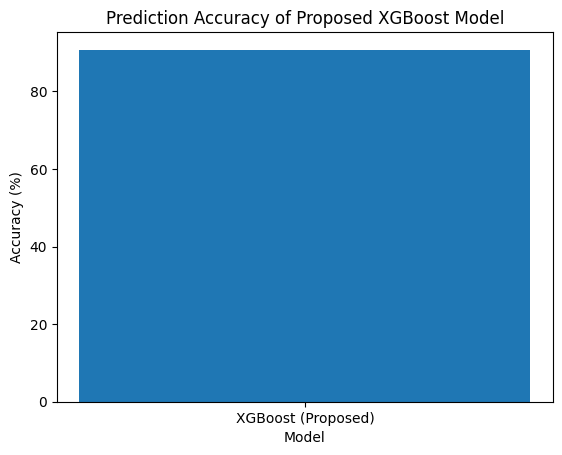

In [17]:
import matplotlib.pyplot as plt

accuracy = r2 * 100

plt.figure()
plt.bar(["XGBoost (Proposed)"], [accuracy])
plt.xlabel("Model")
plt.ylabel("Accuracy (%)")
plt.title("Prediction Accuracy of Proposed XGBoost Model")
plt.show()



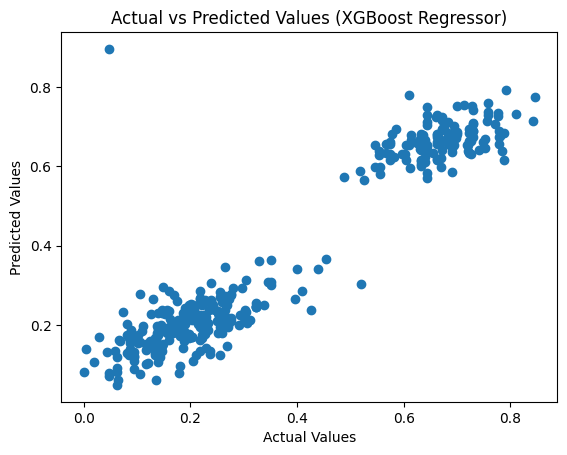

In [18]:
plt.figure()
plt.scatter(y_test, xgb_preds)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values (XGBoost Regressor)")
plt.show()


In [19]:
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score
import numpy as np

kf = KFold(n_splits=5, shuffle=True, random_state=42)

r2_scores = []

for train_idx, val_idx in kf.split(X_scaled):
    X_tr, X_val = X_scaled[train_idx], X_scaled[val_idx]
    y_tr, y_val = y_scaled[train_idx], y_scaled[val_idx]

    model = XGBRegressor(
        n_estimators=500,
        learning_rate=0.03,
        max_depth=7,
        subsample=0.85,
        colsample_bytree=0.85,
        objective="reg:squarederror",
        random_state=42
    )

    model.fit(X_tr, y_tr.ravel())
    preds = model.predict(X_val)
    r2_scores.append(r2_score(y_val, preds))

print("Cross-validated R² scores:", r2_scores)
print("Mean CV Accuracy (%):", np.mean(r2_scores) * 100)


Cross-validated R² scores: [0.9049252719594197, 0.9355161870024691, 0.9341707901671944, 0.8988816219315875, 0.919660976028362]
Mean CV Accuracy (%): 91.86309694178064


In [20]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [300, 500],
    "max_depth": [5, 7],
    "learning_rate": [0.05, 0.03],
    "subsample": [0.8, 0.9]
}

xgb = XGBRegressor(
    objective="reg:squarederror",
    random_state=42
)

grid = GridSearchCV(
    xgb,
    param_grid,
    scoring="r2",
    cv=3,
    n_jobs=-1
)

grid.fit(X_train, y_train.ravel())

print("Best Parameters:", grid.best_params_)
print("Best Accuracy (%):", grid.best_score_ * 100)


Best Parameters: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 500, 'subsample': 0.9}
Best Accuracy (%): 92.48953466353883


In [21]:
!pip install shap


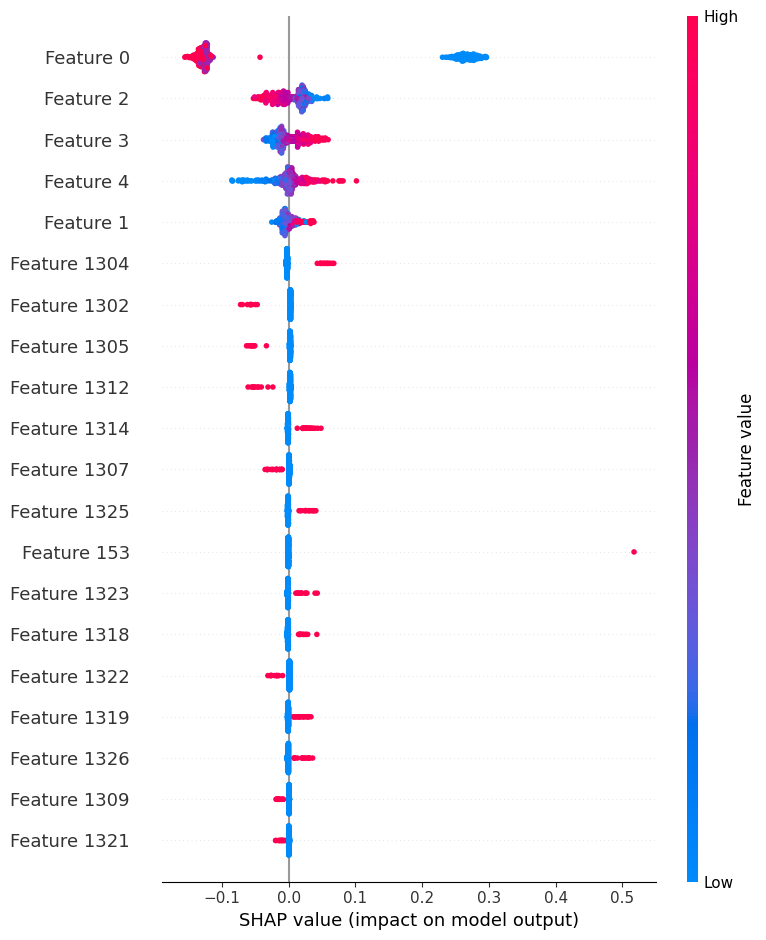

In [22]:
import shap

explainer = shap.Explainer(xgb_model)
shap_values = explainer(X_test)

# Global feature importance
shap.summary_plot(shap_values, X_test, show=True)


In [23]:
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=300, random_state=42)

stack_model = StackingRegressor(
    estimators=[
        ("rf", rf),
        ("xgb", xgb_model)
    ],
    final_estimator=Ridge(alpha=1.0),
    n_jobs=-1
)

stack_model.fit(X_train, y_train.ravel())
stack_preds = stack_model.predict(X_test)

stack_r2 = r2_score(y_test, stack_preds)
print("Stacked Model Accuracy (%):", stack_r2 * 100)


Stacked Model Accuracy (%): 90.95836931151344


In [24]:
import joblib

joblib.dump(xgb_model, "xgboost_agronomy_model.pkl")
print("Model saved successfully!")


Model saved successfully!


In [25]:
loaded_model = joblib.load("xgboost_agronomy_model.pkl")
